# Preprocessing.ipynb


In [1]:
##================ Chargement de quelques modules de base ===================
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


## Chargement des données et pré-traitement préliminaire

In [2]:
##============= Chargement de quelques modules de base ============
# Réglages d'affichage
pd.set_option("display.max_columns", 21)
# Toujours afficher la dimension du dataframe
pd.set_option("display.show_dimensions", True)

# Chemin absolue

project_root = Path.cwd().resolve().parents[0]
src_path = project_root / "src"

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

## import projet
from src.config import RAW_DATA_PATH, RAW_DATA_DIR, TARGET_COL, RANDOM_STATE
from src.utils import load_csv



In [3]:
##========== Chargement du dataset ==============

df_raw = load_csv(RAW_DATA_PATH)
df = df_raw.copy()

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
##================ Pré-traitement des données ==========
df = df.drop("customerID", axis=1, errors="ignore")
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

##======== Création d'ensembles profile_clients, services_souscr_equ, dimension_fin =========
profiles_clients = list(["gender", "SeniorCitizen", "Partner", "Dependents"])
services_souscr_equ = list(["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", 
                           "StreamingTV", "StreamingMovies"])
dimensions_fin = list(["PaperlessBilling", "PaymentMethod"])
charges_clients= list(["MonthlyCharges", "TotalCharges", "tenure"])

In [6]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Valeurs manquantes:
- Sur la partie EDA, on pu constater qu'on a très peu de NaN, une portion très faible (11 valeurs, sur la colonne `TotalCharges`) sur un dataset de 7043 lignes, 
- Je crois donc on peut juste supprimer les échantillons correspondantes, cela nous permettra d'avoir des données plus propres
- Sans que cela est une influence notable sur la quantité des données.

In [7]:
##============ Suppréssion de NaN ====================
df = df.dropna(subset=["TotalCharges"])

## Features Engineering:
- Lors de l'EDA, on a remarqué que les clients récents churn plus vite ou qui sont plus à risque, d'où le choix de créer une variable `tenure_group`, catégorielle qui sera une division de variable `tenure` en trois intervalle que je vais labéliser en "nouveaux", "intermediaires" et "fidèles"
- Puis une autre variable `num_services`, qui elle va compter le nombre de services auquels un client est souscrit, je la trouve informative car un nombres de services important souscrits peut être synonyme d'un client plus engagé autrement dis une probabilité de churn faible
- Et en fin une variable `engagement_level`, qui elle sera une extraction d'information possible sur les autres caractéristiques en particulier la longeur du contrat, beaucoup de services souscrite, ...; en un mot une "variable d'engagement" qui est discriminante aidant à la classification. 

In [8]:
## segmentation clients
df["tenure_groupe"]=pd.cut( df["tenure"], 
                            bins=[0, 12, 24, float("inf")],
                            labels=["nouveaux", "intermédiaires", "fidéle"],
                            right= "False")
## nombre de services souscrites par client
df["num_services"] = (df[services_souscr_equ] == "Yes").sum(axis=1)

In [9]:
## attribue de points si le client montre des signes d’engagement

engagement_score = (
    df["Contract"].isin(["One year", "Two year"]).astype(int)
    + (df["num_services"] >= 3).astype(int)
    + df["InternetService"].isin(["DSL", "Fiber optic"]).astype(int)
    + df["PaymentMethod"].isin([
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ]).astype(int)
)

In [10]:
## creation de notre variable d'engagement à l'aide de engagement score

df["engagement_level"] = pd.cut(
    engagement_score,
    bins=[-1, 1, 3, 4],
    labels=["faible", "moyen", "élevé"]
)

In [11]:
#================ dataframe après feature engineering ========
df.head()
#============ disvision du dataframe par classe ========

churner_df=df[df["Churn"]== "Yes"]
non_churner_df=df[df["Churn"]== "No"]

/var/folders/tn/1_8rqk3x16q7_173ngbntzp40000gn/T/ipykernel_907/2086816429.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(churner_df["num_services"], label="churner", kde=True, bins= "fd")
/var/folders/tn/1_8rqk3x16q7_173ngbntzp40000gn/T/ipykernel_907/2086816429.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750b

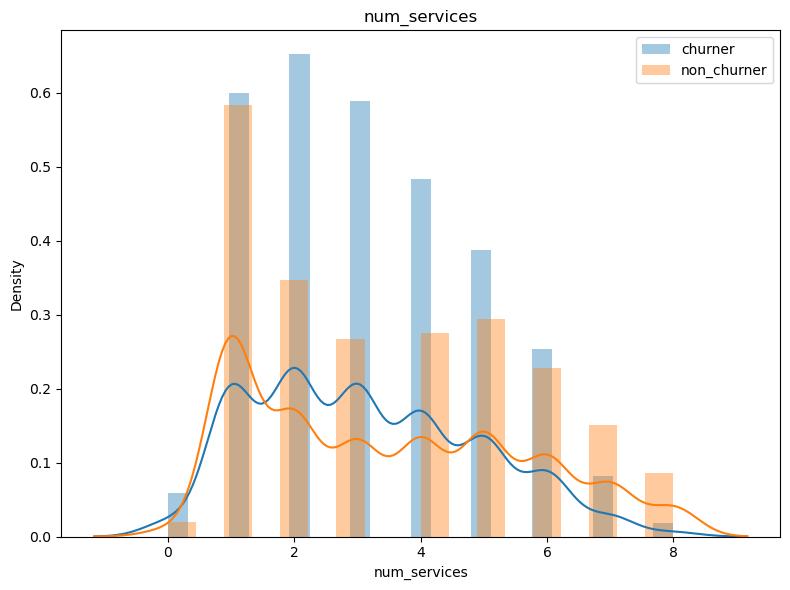

In [12]:
## Visualisation de la relation churn/ variables créer 
plt.figure(figsize=(8, 6))

sns.distplot(churner_df["num_services"], label="churner", kde=True, bins= "fd")
sns.distplot(non_churner_df["num_services"], label="non_churner", kde=True, bins= "fd")

plt.title("num_services")
plt.legend()
plt.tight_layout()
plt.show()

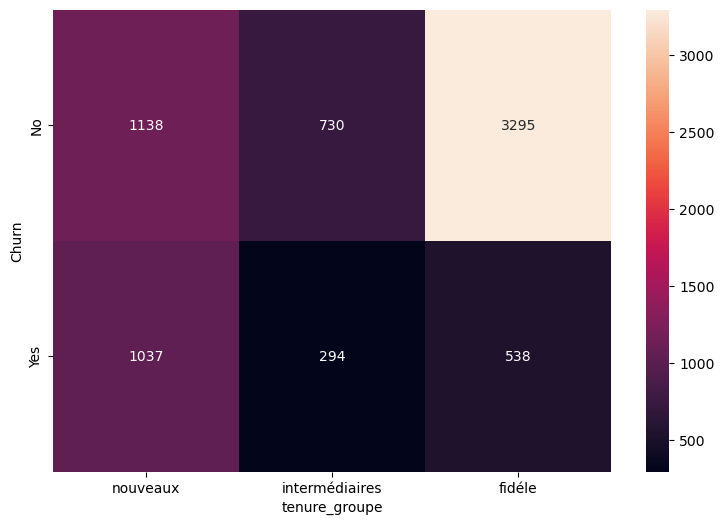

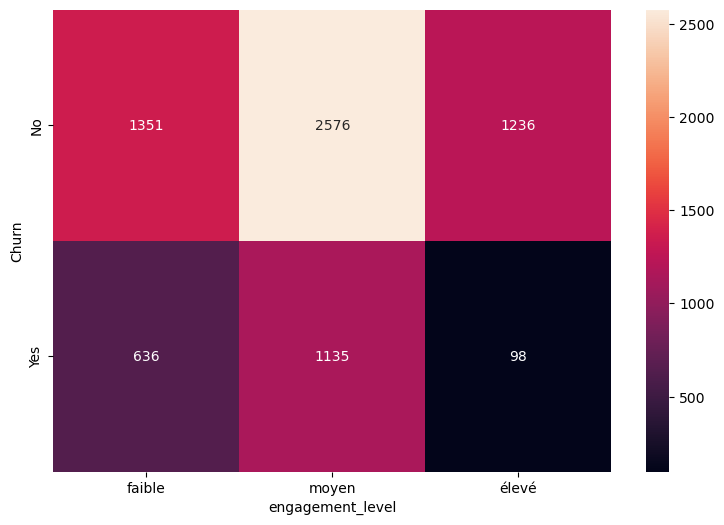

In [13]:
## visualisation relation tenure_groupe & churn et engagement_level & churn

for col in ["tenure_groupe", "engagement_level"]:


    plt.figure(figsize=(9, 6))
    sns.heatmap(pd.crosstab(df["Churn"], df[col]), annot=True, fmt='d')

In [14]:
##======= matrice des features X & varible cible y ===========

X = df.drop(columns = [TARGET_COL])

y= df[TARGET_COL]

## Trainset/ Validationset/ Testset

In [16]:
##============== Split 1: trainset 70% des données et tempset 30% des données ============

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.3, random_state = RANDOM_STATE, stratify=y)

##============== Split 2: Validationset 15% des données et Testset 15% des données ============

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = RANDOM_STATE, stratify=y_temp)

## Construction du Pipeline

In [20]:
##============= création de la liste des variables numériques num_cols et catégorielles cat_cols =======
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(exclude=np.number).columns

In [21]:
##============ création de pipelines par groupe de variables =============

numeric = Pipeline(steps = [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ])

categorical = Pipeline(steps = [("imputer", SimpleImputer(strategy="most_frequent")), 
                                ("onehot", OneHotEncoder(handle_unknown="ignore")), ])


In [22]:
##============ Créatiion d'un transformeur preprocess, via ColumnTransformer ======

preprocess = ColumnTransformer(
    transformers = [("num", numeric, num_cols), ("cat", categorical, cat_cols)], remainder = "drop")